# Lesson 1: The Python language

In [113]:
!git clone https://github.com/hsf-training/array-oriented-programming.git
!cp -r array-oriented-programming/data ./data
#had to clone b/c I am working in codespace


fatal: destination path 'array-oriented-programming' already exists and is not an empty directory.


cp: cannot stat 'array-oriented-programming/data': No such file or directory


In [219]:
import json
import math

import numpy as np
import matplotlib.pyplot as plt

from hepunits import GeV
from particle import Particle
import vector
from hist import Hist

dataset = json.load(open("array-oriented-programming/array-oriented-programming/data/SMHiggsToZZTo4L.json"))

def to_vector(particle):
    return vector.obj(
        pt=particle["pt"],
        eta=particle["eta"],
        phi=particle["phi"],
        mass=particle["mass"],
    )

electrons_and_muons = []   #leptons

event = dataset[96] 

for particle in event["electron"]:
    electrons_and_muons.append({
        "type": "electron",
        "charge": particle["charge"],
        "vector": to_vector(particle),
    })

for particle in event["muon"]:
    electrons_and_muons.append({
        "type": "muon",
        "charge": particle["charge"],
        "vector": to_vector(particle),
    })

z_candidates_step0 = []

for index_i, particle_i in enumerate(electrons_and_muons):
    for index_j, particle_j in enumerate(electrons_and_muons):
        if index_i < index_j:
            z_candidates_step0.append({
                "index": [index_i, index_j],
                "types": [particle_i["type"], particle_j["type"]],
                "charge": particle_i["charge"] + particle_j["charge"],
                "vector": particle_i["vector"] + particle_j["vector"],
            })

## Exercise part 1

In [220]:
z_candidates_step1 = []

for candidate in z_candidates_step0:
    #the charges have to be opposite, so they sum to zero
    if candidate["charge"] == 0 and candidate["types"][0] == candidate["types"][1]:
        z_candidates_step1.append(candidate)

for candidate in z_candidates_step1:
    print(candidate["types"], candidate["vector"].mass)


['electron', 'electron'] 94.65200565609618
['electron', 'electron'] 3.417050436103103
['muon', 'muon'] 26.45024522236556
['muon', 'muon'] 3.2737370390909524


## Exercise part 2

In [221]:
higgs_candidates_step1 = []

for z_index1, z_candidate1 in enumerate(z_candidates_step1):
    for z_index2, z_candidate2 in enumerate(z_candidates_step1):
        if z_index1 < z_index2:
            lepton_i1, lepton_j1 = z_candidate1["index"]
            lepton_i2, lepton_j2 = z_candidate2["index"]
            #a lepton can't belong to both Z decays at the same time
            #using a set here b/c if any indices are the same, the set will have less than 4 elements
            if len({lepton_i1, lepton_j1, lepton_i2, lepton_j2}) == 4:
                higgs_candidates_step1.append({
                    "z_candidates": [z_candidate1, z_candidate2],
                    "vector": z_candidate1["vector"] + z_candidate2["vector"],
                })

for higgs_candidate in higgs_candidates_step1:
    z_candidate1, z_candidate2 = higgs_candidate["z_candidates"]
    lepton_index1, lepton_index2 = z_candidate1["index"]
    lepton_index3, lepton_index4 = z_candidate2["index"]
    print(
        lepton_index1,
        lepton_index2,
        lepton_index3,
        lepton_index4,
        higgs_candidate["vector"].mass,
    )

higgs_candidates_step2 = {}

for higgs_candidate in higgs_candidates_step1:
    z_candidate1, z_candidate2 = higgs_candidate["z_candidates"]
    lepton_index1, lepton_index2 = z_candidate1["index"]
    lepton_index3, lepton_index4 = z_candidate2["index"]

    combination = tuple(sorted([
        lepton_index1, lepton_index2, lepton_index3, lepton_index4
    ]))

    if combination not in higgs_candidates_step2:
        higgs_candidates_step2[combination] = []

    higgs_candidates_step2[combination].append(higgs_candidate)

for combination in higgs_candidates_step2:
    print(combination)
    for higgs_candidate in higgs_candidates_step2[combination]:
        z_candidate1, z_candidate2 = higgs_candidate["z_candidates"]
        print(
            "    Higgs:",
            higgs_candidate["vector"].mass,
            "Z:",
            z_candidate1["vector"].mass,
            z_candidate2["vector"].mass,
        )

0 2 3 4 129.0346159691587
0 2 3 5 118.8311777089631
1 2 3 4 56.10989169721264
1 2 3 5 12.750734071856588
(0, 2, 3, 4)
    Higgs: 129.0346159691587 Z: 94.65200565609618 26.45024522236556
(0, 2, 3, 5)
    Higgs: 118.8311777089631 Z: 94.65200565609618 3.2737370390909524
(1, 2, 3, 4)
    Higgs: 56.10989169721264 Z: 3.417050436103103 26.45024522236556
(1, 2, 3, 5)
    Higgs: 12.750734071856588 Z: 3.417050436103103 3.2737370390909524


## Exercise part 3

In [222]:
higgs_candidates_step3 = {}

for combination in higgs_candidates_step2:
    higgs_candidates_step3[combination] = []

    for higgs_candidate in higgs_candidates_step2[combination]:
        z_candidate1, z_candidate2 = higgs_candidate["z_candidates"]
        #need to figure out which Z is heavier and which is lighter b/c the cuts are different for each
        smallest_z_mass = min(z_candidate1["vector"].mass, z_candidate2["vector"].mass)
        largest_z_mass = max(z_candidate1["vector"].mass, z_candidate2["vector"].mass)
        
        #the lighter Z can be off-shell but not too far off, the heavier one should be close to 91 GeV
        if 12 < smallest_z_mass < 120 and 40 < largest_z_mass < 120:
            higgs_candidates_step3[combination].append(higgs_candidate)

for combination in higgs_candidates_step3:
    print(combination)
    for higgs_candidate in higgs_candidates_step3[combination]:
        z_candidate1, z_candidate2 = higgs_candidate["z_candidates"]
        print(
            "    Higgs:",
            higgs_candidate["vector"].mass,
            "Z:",
            z_candidate1["vector"].mass,
            z_candidate2["vector"].mass,
        )

(0, 2, 3, 4)
    Higgs: 129.0346159691587 Z: 94.65200565609618 26.45024522236556
(0, 2, 3, 5)
(1, 2, 3, 4)
(1, 2, 3, 5)


# Lesson 2: Higgs decays from arrays

In [256]:
dataset_hdf5 = h5py.File("data/SMHiggsToZZTo4L.h5")

e1 = vector.array({
    "pt": dataset_hdf5["ee_mumu"]["e1"]["pt"],
    "phi": dataset_hdf5["ee_mumu"]["e1"]["phi"],
    "eta": dataset_hdf5["ee_mumu"]["e1"]["eta"],
    "mass": dataset_hdf5["ee_mumu"]["e1"]["mass"],
})
e2 = vector.array({
    "pt": dataset_hdf5["ee_mumu"]["e2"]["pt"],
    "phi": dataset_hdf5["ee_mumu"]["e2"]["phi"],
    "eta": dataset_hdf5["ee_mumu"]["e2"]["eta"],
    "mass": dataset_hdf5["ee_mumu"]["e2"]["mass"],
})
mu1 = vector.array({
    "pt": dataset_hdf5["ee_mumu"]["mu1"]["pt"],
    "phi": dataset_hdf5["ee_mumu"]["mu1"]["phi"],
    "eta": dataset_hdf5["ee_mumu"]["mu1"]["eta"],
    "mass": dataset_hdf5["ee_mumu"]["mu1"]["mass"],
})
mu2 = vector.array({
    "pt": dataset_hdf5["ee_mumu"]["mu2"]["pt"],
    "phi": dataset_hdf5["ee_mumu"]["mu2"]["phi"],
    "eta": dataset_hdf5["ee_mumu"]["mu2"]["eta"],
    "mass": dataset_hdf5["ee_mumu"]["mu2"]["mass"],
})

zmass_ee = (e1 + e2).mass
zmass_mumu = (mu1 + mu2).mass

e1_charge = np.asarray(dataset_hdf5["ee_mumu"]["e1"]["charge"])
e2_charge = np.asarray(dataset_hdf5["ee_mumu"]["e2"]["charge"])
mu1_charge = np.asarray(dataset_hdf5["ee_mumu"]["mu1"]["charge"])
mu2_charge = np.asarray(dataset_hdf5["ee_mumu"]["mu2"]["charge"])

##  Exercise part 1

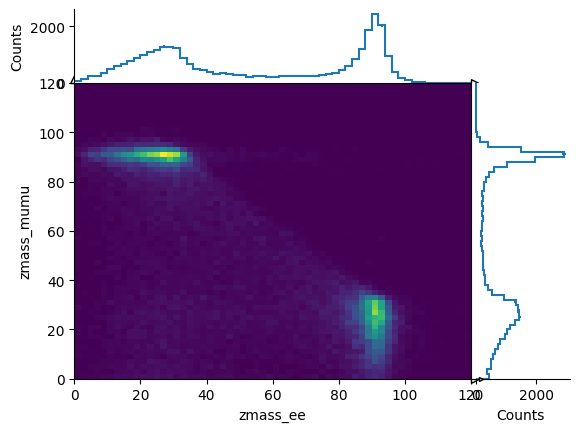

In [257]:
#2D histogram to see the correlation between the two Z masses
#should see hotspots where one/both Z bosons are near ~91 GeV
Hist.new.Regular(60, 0, 120, name="zmass_ee").Regular(60, 0, 120, name="zmass_mumu").Double().fill(
    zmass_ee=zmass_ee, zmass_mumu=zmass_mumu
).plot2d_full();

##  Exercise part 2

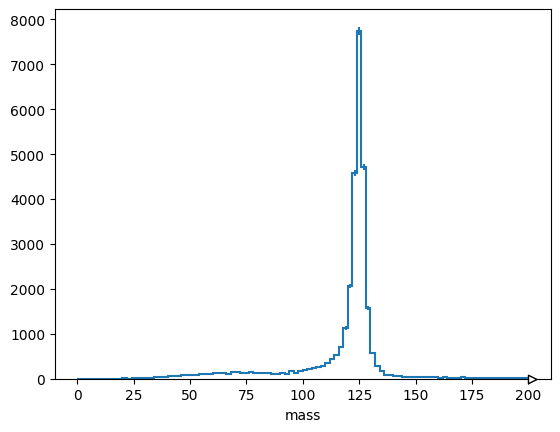

In [258]:
#the Higgs is the parent of both Z bosons, so its 4-momentum = sum of all 4 leptons
#expect peak around 125 GeV
higgs_mass = (e1 + e2 + mu1 + mu2).mass

Hist.new.Regular(100, 0, 200, name="mass").Double().fill(higgs_mass).plot();

## Exercise part 3

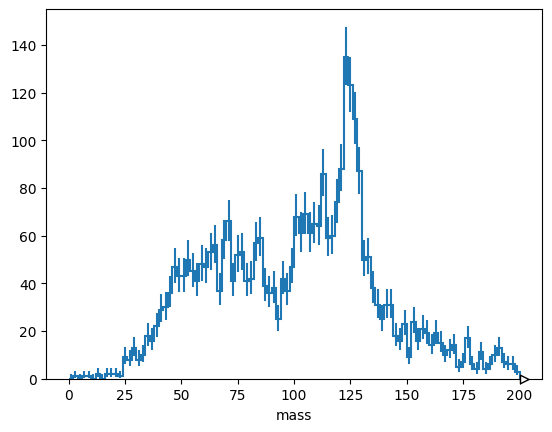

In [259]:
#using ~ (not) to flip the boolean mask -> we get events that FAIL the charge cut
#these are events where the electrons or muons don't have opposite charges
fail_charge = ~((e1_charge + e2_charge == 0) & (mu1_charge + mu2_charge == 0))

Hist.new.Regular(100, 0, 200, name="mass").Double().fill(
    higgs_mass[fail_charge]
).plot();

## Exercise part 4

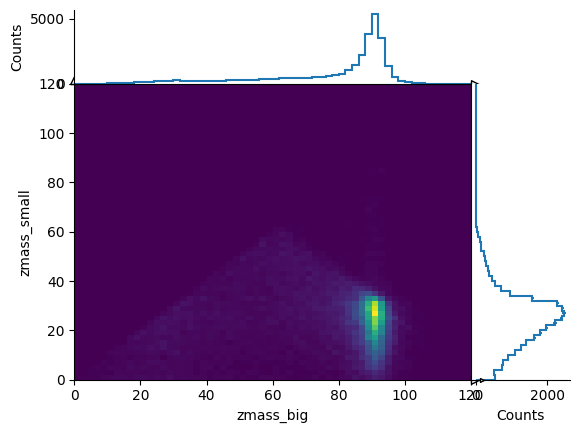

In [260]:
#np.where works 1 element at a time -> for each event, pick the smaller/bigger Z mass
#can't just use min() b/c these are arrays, not single numbers
zmass_small = np.where(zmass_ee < zmass_mumu, zmass_ee, zmass_mumu)
zmass_big = np.where(zmass_ee > zmass_mumu, zmass_ee, zmass_mumu)

#should see a triangular shape because zmass_small is always <= zmass_big by definition
Hist.new.Regular(60, 0, 120, name="zmass_big").Regular(60, 0, 120, name="zmass_small").Double().fill(
    zmass_big=zmass_big, zmass_small=zmass_small
).plot2d_full();

## Exercise part 5

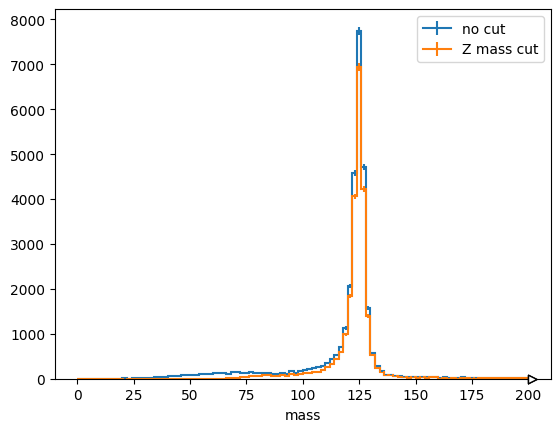

In [261]:
#the same mass window cuts as in lesson 1
#the idea is that at least one Z should be near on-shell (91 GeV)
z_mass_cut = (12 < zmass_small) & (zmass_small < 120) & (40 < zmass_big) & (zmass_big < 120)

fig, ax = plt.subplots(1, 1)

#plot without cut first for comparison
Hist.new.Regular(100, 0, 200, name="mass").Double().fill(
    higgs_mass
).plot(ax=ax, label="no cut");

#then overlay with cut -> should see the peak get sharper around 125 GeV
Hist.new.Regular(100, 0, 200, name="mass").Double().fill(
    higgs_mass[z_mass_cut]
).plot(ax=ax, label="Z mass cut");

ax.legend();

## Exercise ('for fun' apparently)

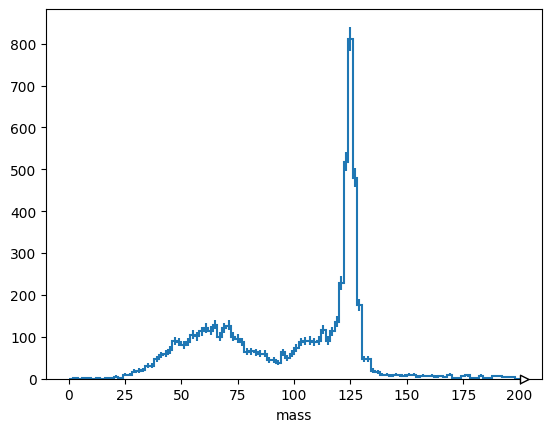

In [262]:
#"bad" events = no clear Higgs peak
Hist.new.Regular(100, 0, 200, name="mass").Double().fill(
    higgs_mass[~z_mass_cut]
).plot();

# Lesson 3: Higgs combinatorics from arrays

In [263]:
!pip install pyarrow

import awkward as ak
vector.register_awkward()

events = ak.from_parquet("data/SMHiggsToZZTo4L.parquet")


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [289]:
eplus = events.electron[events.electron.charge > 0]
eminus = events.electron[events.electron.charge < 0]
eplusplus = ak.combinations(eplus, 2)
eminusminus = ak.combinations(eminus, 2)
epairs_of_pairs = ak.cartesian([eplusplus, eminusminus])

interpretation1_z1 = epairs_of_pairs["0", "0"] + epairs_of_pairs["1", "0"]
interpretation1_z2 = epairs_of_pairs["0", "1"] + epairs_of_pairs["1", "1"]

interpretation2_z1 = epairs_of_pairs["0", "0"] + epairs_of_pairs["1", "1"]
interpretation2_z2 = epairs_of_pairs["0", "1"] + epairs_of_pairs["1", "0"]

## Exercise 1

In [290]:
#sorting 2 Z candidates by mass within each interpretation
#ak.where is like np.where but works on awkward arrays with variable length lists
interpretation1_zsmall = ak.where(interpretation1_z1.mass < interpretation1_z2.mass, interpretation1_z1, interpretation1_z2)
interpretation1_zbig   = ak.where(interpretation1_z1.mass > interpretation1_z2.mass, interpretation1_z1, interpretation1_z2)

#different e+/e- pairing
interpretation2_zsmall = ak.where(interpretation2_z1.mass < interpretation2_z2.mass, interpretation2_z1, interpretation2_z2)
interpretation2_zbig   = ak.where(interpretation2_z1.mass > interpretation2_z2.mass, interpretation2_z1, interpretation2_z2)

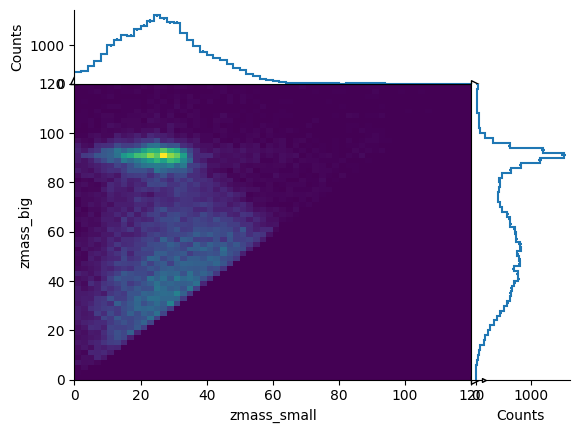

In [291]:
Hist.new.Regular(60, 0, 120, name="zmass_small").Regular(60, 0, 120, name="zmass_big").Double().fill(
    zmass_small=ak.flatten(interpretation1_zsmall.mass),
    zmass_big=ak.flatten(interpretation1_zbig.mass),
).plot2d_full();

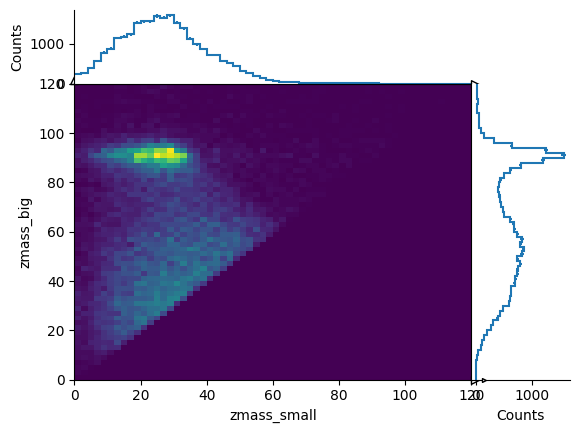

In [292]:
Hist.new.Regular(60, 0, 120, name="zmass_small").Regular(60, 0, 120, name="zmass_big").Double().fill(
    zmass_small=ak.flatten(interpretation2_zsmall.mass),
    zmass_big=ak.flatten(interpretation2_zbig.mass),
).plot2d_full();

## Exercise 2

In [293]:
#same mass window cuts as before but now for each interpretation separately
#want to see which interpretation gives a cleaner Higgs signal
interpretation1_quality = (
    (12 < interpretation1_zsmall.mass) & (interpretation1_zsmall.mass < 120)
    & (40 < interpretation1_zbig.mass) & (interpretation1_zbig.mass < 120)
)

interpretation2_quality = (
    (12 < interpretation2_zsmall.mass) & (interpretation2_zsmall.mass < 120) 
    & (40 < interpretation2_zbig.mass) & (interpretation2_zbig.mass < 120)
)

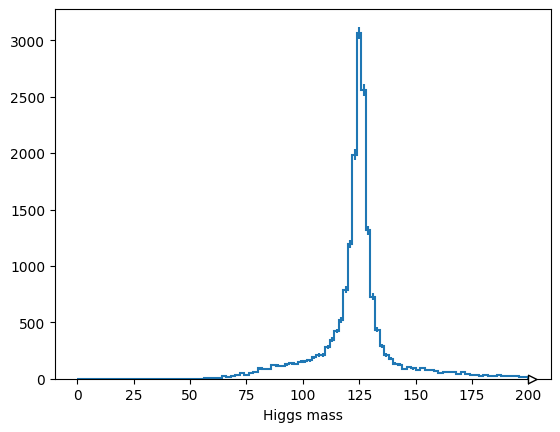

In [294]:
Hist.new.Regular(100, 0, 200, name="Higgs mass").Double().fill(
    ak.flatten((interpretation1_zsmall + interpretation1_zbig).mass[interpretation1_quality])
).plot();

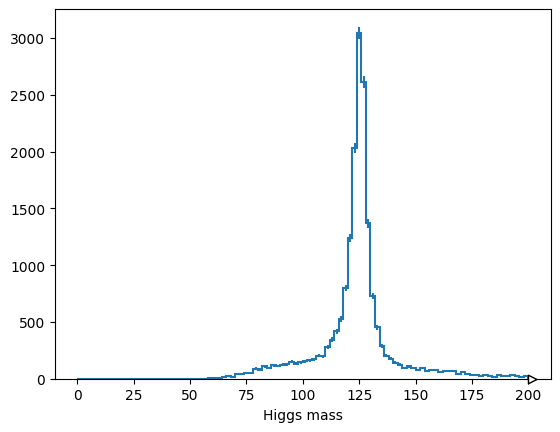

In [295]:
Hist.new.Regular(100, 0, 200, name="Higgs mass").Double().fill(
    ak.flatten((interpretation2_zsmall + interpretation2_zbig).mass[interpretation2_quality])
).plot();

## Exercise 3

In [296]:
from particle import Particle
from hepunits import GeV

#getting the actual Z mass from the PDG database
onshell_mass = Particle.from_name("Z0").mass / GeV

#whichever interpretation has the big Z closer to 91.2 GeV is probs the right one
#using abs() to compare the distance from the on-shell mass
interpretation1_is_best = abs(interpretation1_zbig.mass - onshell_mass) < abs(interpretation2_zbig.mass - onshell_mass)

#ak.where picks from interp1 or interp2 candidate by candidate
best_interpretation_zbig = ak.where(interpretation1_is_best, interpretation1_zbig, interpretation2_zbig)
best_interpretation_zsmall = ak.where(interpretation1_is_best, interpretation1_zsmall, interpretation2_zsmall)

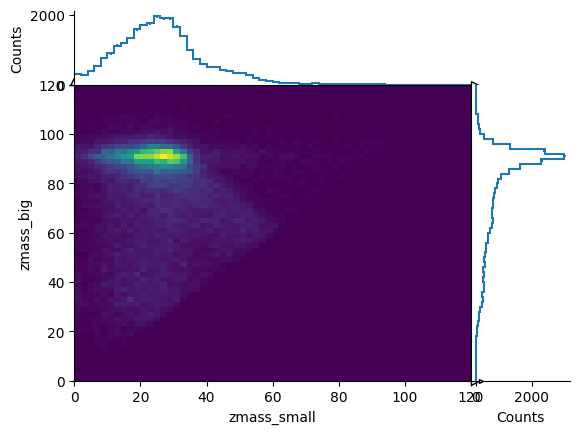

In [297]:
Hist.new.Regular(60, 0, 120, name="zmass_small").Regular(60, 0, 120, name="zmass_big").Double().fill(
    zmass_small=ak.flatten(best_interpretation_zsmall.mass),
    zmass_big=ak.flatten(best_interpretation_zbig.mass),
).plot2d_full();

## Exercise 4

In [298]:
#might still have multiple Higgs candidates per event
#got to pick the one whose big Z is closest to the on-shell mass
#argmin gives us the index of the minimum value in each list
best_higgs_candidate_index = ak.argmin(abs(best_interpretation_zbig.mass - onshell_mass), axis=-1, keepdims=True)

#use index to select just one candidate per event
#the [:, 0] removes the extra dimension from keepdims=True
best_higgs_zbig = best_interpretation_zbig[best_higgs_candidate_index][:, 0]
best_higgs_zsmall = best_interpretation_zsmall[best_higgs_candidate_index][:, 0]

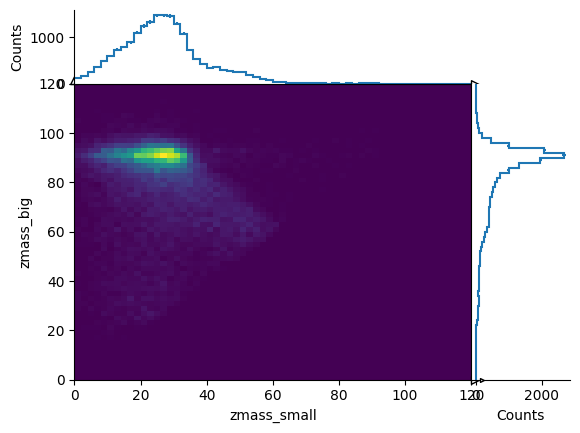

In [299]:
Hist.new.Regular(60, 0, 120, name="zmass_small").Regular(60, 0, 120, name="zmass_big").Double().fill(
    zmass_small=ak.flatten(best_higgs_zsmall.mass, axis=0),
    zmass_big=ak.flatten(best_higgs_zbig.mass, axis=0),
).plot2d_full();

## Exercise 5

In [300]:
#final cut on the best candidate per event
#same mass windows as always
best_interpretation_quality = (
    (12 < best_higgs_zsmall.mass) & (best_higgs_zsmall.mass < 120) &
    (40 < best_higgs_zbig.mass) & (best_higgs_zbig.mass < 120)
)

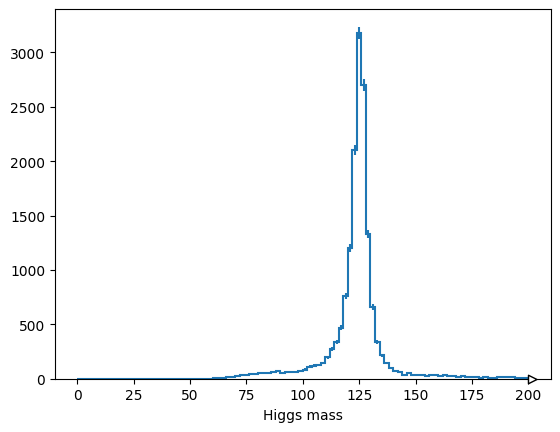

In [301]:
Hist.new.Regular(100, 0, 200, name="Higgs mass").Double().fill(
    ak.flatten((best_higgs_zsmall + best_higgs_zbig).mass[best_interpretation_quality], axis=0)
).plot();

# Lesson 4: JIT-compiled Higgs combinatorics

In [302]:
!pip install numba
import numba as nb
#same approach as lesson 3
eplus = events.electron[events.electron.charge > 0]
eminus = events.electron[events.electron.charge < 0]

#finding an event with 3 e+ and 3 e- so we have enough for interesting combinatorics
np.nonzero((ak.num(eplus) == 3) & (ak.num(eminus) == 3))

#picking event 448 -> it has 3 positrons and 3 electrons, good for testing
eplus_event = eplus[448]
eminus_event = eminus[448]
eplus_event.show()
eminus_event.show()


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
[{pt: 39.4, eta: 0.865, phi: 1.53, mass: 0.00949, charge: 1, ...},
 {pt: 68, eta: 0.681, phi: 0.922, mass: -0.0151, charge: 1, ...},
 {pt: 8.35, eta: -0.359, phi: -1.88, mass: 0.00204, charge: 1, ...}]
[{pt: 9.69, eta: -0.818, phi: -2.42, mass: 0.00165, charge: -1, ...},
 {pt: 53.7, eta: 1.41, phi: 2.29, mass: 0.0105, charge: -1, ...},
 {pt: 57, eta: 0.946, phi: 1.75, mass: 0.0233, charge: -1, ...}]


## Exercise 1

In [314]:
#iterating over all unique pairs of e+ indices and all unique pairs of e- indices
#Z1 gets one e+ and one e-, Z2 gets a different e+ and a different e-
#using range with offsets to avoid giving the same particle to both Z bosons
print( "e+ index  | e- index ")
print(f"Z1_i Z2_i | Z1_j Z2_j")
print( "----------+----------")
for Z1_i in range(len(eplus_event)):
    for Z2_i in range(Z1_i + 1, len(eplus_event)):
        for Z1_j in range(len(eminus_event)):
            for Z2_j in range(Z1_j + 1, len(eminus_event)):
                print(f"{Z1_i:4d} {Z2_i:4d} | {Z1_j:4d} {Z2_j:4d}")
        print( "----------+----------")

e+ index  | e- index 
Z1_i Z2_i | Z1_j Z2_j
----------+----------
   0    1 |    0    1
   0    1 |    0    2
   0    1 |    1    2
----------+----------
   0    2 |    0    1
   0    2 |    0    2
   0    2 |    1    2
----------+----------
   1    2 |    0    1
   1    2 |    0    2
   1    2 |    1    2
----------+----------


## Exercise 2

In [315]:
#for each combination, reconstruct the 2 Z bosons and figure out which is heavier
#using a pretty simple tuple swap to assign Zsmall and Zbig
print( " Zsmall  |  Zbig   ")
print( "---------+---------")
for Z1_i in range(len(eplus_event)):
    for Z2_i in range(Z1_i + 1, len(eplus_event)):
        for Z1_j in range(len(eminus_event)):
            for Z2_j in range(Z1_j + 1, len(eminus_event)):
                Z1 = eplus_event[Z1_i] + eminus_event[Z1_j]
                Z2 = eplus_event[Z2_i] + eminus_event[Z2_j]
                #swap so Zsmall always has the lower mass
                Zsmall, Zbig = (Z1, Z2) if Z1.mass < Z2.mass else (Z2, Z1)
                print(f"{Zsmall.mass:.5f} | {Zbig.mass:.5f}")
        print( "---------+---------")

 Zsmall  |  Zbig   
---------+---------
51.54425 | 88.57392
51.54425 | 52.81760
42.52653 | 52.81760
---------+---------
51.54425 | 56.26014
51.54425 | 52.19812
42.52653 | 52.19812
---------+---------
56.26014 | 66.23705
52.19812 | 66.23705
52.19812 | 88.57392
---------+---------


## Exercise 3 

In [316]:
onshell_mass = Particle.from_name("Z0").mass / GeV

def best_interpretation(eplus_event, eminus_event):
    #start with None because some events might not have enough electrons
    best_Zsmall, best_Zbig = None, None
    for Z1_i in range(len(eplus_event)):
        for Z2_i in range(Z1_i + 1, len(eplus_event)):
            for Z1_j in range(len(eminus_event)):
                for Z2_j in range(Z1_j + 1, len(eminus_event)):
                    Z1 = eplus_event[Z1_i] + eminus_event[Z1_j]
                    Z2 = eplus_event[Z2_i] + eminus_event[Z2_j]
                    #figure out which Z is lighter and which is heavier
                    Zsmall, Zbig = (Z1, Z2) if Z1.mass < Z2.mass else (Z2, Z1)
                    #keep the combination where Zbig is closest to the real Z mass
                    #on first iteration best_Zbig is None so we always accept
                    if best_Zbig is None or abs(Zbig.mass - onshell_mass) < abs(best_Zbig.mass - onshell_mass):
                        best_Zsmall, best_Zbig = Zsmall, Zbig
    return best_Zsmall, best_Zbig

best_interpretation(eplus_event, eminus_event)

(<MomentumRecord4D {rho: 33.4, phi: 1.74, eta: 0.799, ...} type='Momentum4D[...'>,
 <MomentumRecord4D {rho: 94.7, phi: 1.51, eta: 1.26, ...} type='Momentum4D[r...'>)

In [317]:
@nb.njit
def best_interpretation(eplus_event, eminus_event):
    #same function as above but now JIT-compiled by Numba for speed
    best_Zsmall, best_Zbig = None, None
    for Z1_i in range(len(eplus_event)):
        for Z2_i in range(Z1_i + 1, len(eplus_event)):
            for Z1_j in range(len(eminus_event)):
                for Z2_j in range(Z1_j + 1, len(eminus_event)):
                    Z1 = eplus_event[Z1_i] + eminus_event[Z1_j]
                    Z2 = eplus_event[Z2_i] + eminus_event[Z2_j]
                    Zsmall, Zbig = (Z1, Z2) if Z1.mass < Z2.mass else (Z2, Z1)
                    if best_Zbig is None or abs(Zbig.mass - onshell_mass) < abs(best_Zbig.mass - onshell_mass):
                        best_Zsmall, best_Zbig = Zsmall, Zbig
    return best_Zsmall, best_Zbig

best_interpretation(eplus_event, eminus_event)

(MomentumObject4D(pt=33.42538833618164, phi=1.739370346069336, eta=0.799430251121521, mass=51.54425404275518),
 MomentumObject4D(pt=94.71172332763672, phi=1.511854887008667, eta=1.2571223974227905, mass=88.57390943741467))

## Exercise 4

In [318]:
#running on just 100 events first to make sure the logic is correct before compiling
def best_interpretation_per_event(eplus, eminus):
    #using nan for events that don't have valid candidates
    zmass_small = np.empty(len(eplus), dtype=np.float64)
    zmass_big = np.empty(len(eplus), dtype=np.float64)
    higgsmass = np.empty(len(eplus), dtype=np.float64)
    for i, (eplus_event, eminus_event) in enumerate(zip(eplus, eminus)):
        best_Zsmall, best_Zbig = best_interpretation(eplus_event, eminus_event)
        if best_Zsmall is not None and best_Zbig is not None:
            zmass_small[i] = best_Zsmall.mass
            zmass_big[i] = best_Zbig.mass
            #apply the same mass window quality cut as before
            if 12 < best_Zsmall.mass < 120 and 40 < best_Zbig.mass < 120:
                higgsmass[i] = (best_Zsmall + best_Zbig).mass
            else:
                higgsmass[i] = np.nan
        else:
            zmass_small[i] = np.nan
            zmass_big[i] = np.nan
            higgsmass[i] = np.nan
    return zmass_small, zmass_big, higgsmass

#test on small subset first
zmass_small, zmass_big, higgsmass = best_interpretation_per_event(eplus[:100], eminus[:100])

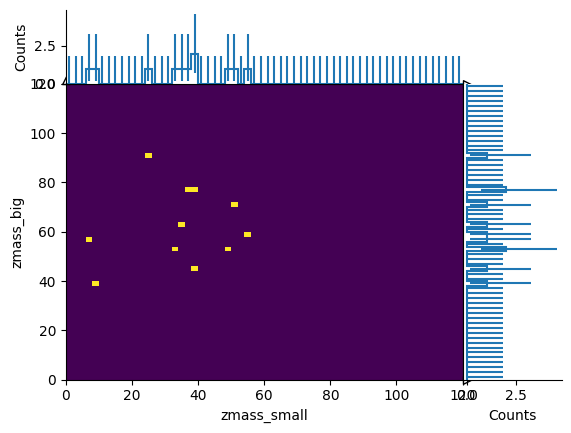

In [319]:
Hist.new.Regular(60, 0, 120, name="zmass_small").Regular(60, 0, 120, name="zmass_big").Double().fill(
    zmass_small=zmass_small,
    zmass_big=zmass_big,
).plot2d_full();

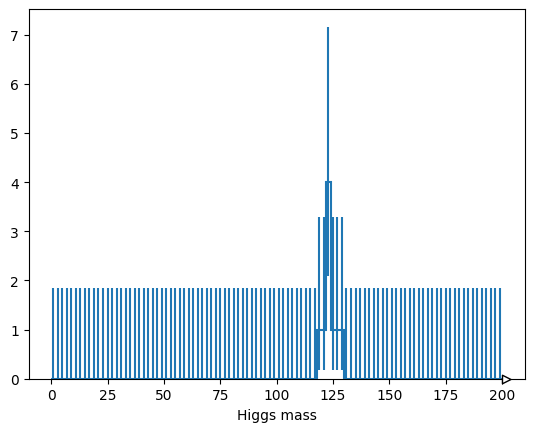

In [320]:
Hist.new.Regular(100, 0, 200, name="Higgs mass").Double().fill(
    higgsmass
).plot();

In [321]:
@nb.njit
def best_interpretation_per_event(eplus, eminus):
    #same logic but now Numba compiles it -> much faster for large datasets
    zmass_small = np.empty(len(eplus), dtype=np.float64)
    zmass_big = np.empty(len(eplus), dtype=np.float64)
    higgsmass = np.empty(len(eplus), dtype=np.float64)
    for i, (eplus_event, eminus_event) in enumerate(zip(eplus, eminus)):
        best_Zsmall, best_Zbig = best_interpretation(eplus_event, eminus_event)
        if best_Zsmall is not None and best_Zbig is not None:
            zmass_small[i] = best_Zsmall.mass
            zmass_big[i] = best_Zbig.mass
            if 12 < best_Zsmall.mass < 120 and 40 < best_Zbig.mass < 120:
                higgsmass[i] = (best_Zsmall + best_Zbig).mass
            else:
                higgsmass[i] = np.nan
        else:
            zmass_small[i] = np.nan
            zmass_big[i] = np.nan
            higgsmass[i] = np.nan
    return zmass_small, zmass_big, higgsmass

#now run on the full dataset (noticeably faster than pure Python: Python took 8.2 seconds and this took 1.7 seconds)
zmass_small, zmass_big, higgsmass = best_interpretation_per_event(eplus, eminus)

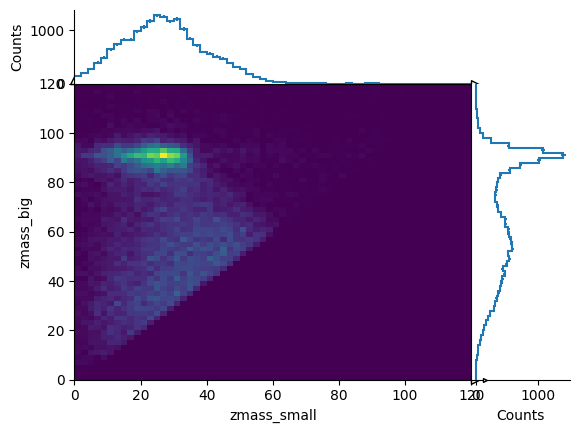

In [322]:
Hist.new.Regular(60, 0, 120, name="zmass_small").Regular(60, 0, 120, name="zmass_big").Double().fill(
    zmass_small=zmass_small,
    zmass_big=zmass_big,
).plot2d_full();

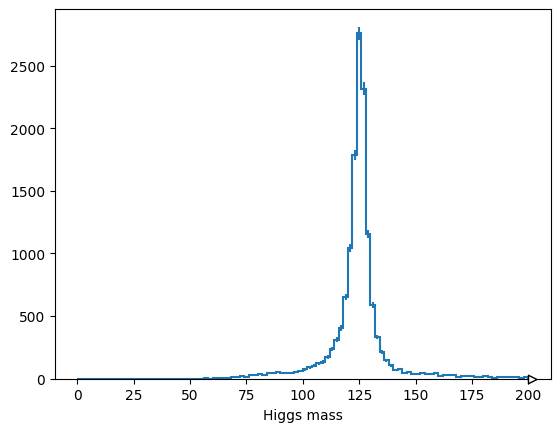

In [323]:
Hist.new.Regular(100, 0, 200, name="Higgs mass").Double().fill(
    higgsmass
).plot();

# Lesson 5: Histograms and Monte Carlo on GPUs

In [324]:
#Unfortunately we have it a paywall. This task requires a GPU and I, respectfully, am not paying for premium GitHub Codespace just yet. 